1. Data Import and Cleaning:

 - Import the dataset using Pandas.
 - Identify missing values and handle them appropriately.
 - Use NumPy to convert relevant columns to numerical types if necessary.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm


In [3]:
df = pd.read_csv('global_power_plant_database.csv', dtype={'other_fuel1': str, 'other_fuel2': str, 'other_fuel3': str})

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  str    
 1   country_long                    34936 non-null  str    
 2   name                            34936 non-null  str    
 3   gppd_idnr                       34936 non-null  str    
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  str    
 8   other_fuel1                     1944 non-null   str    
 9   other_fuel2                     276 non-null    str    
 10  other_fuel3                     92 non-null     str    
 11  commissioning_year              17447 non-null  float64
 12  owner                           20868 non-n

In [5]:
df.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [6]:
# Check for missing values during preprocessing
missing_values = df.isnull().sum()
print("Missing values by column:")
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

Missing values by column:
country                               0
country_long                          0
name                                  0
gppd_idnr                             0
capacity_mw                           0
latitude                              0
longitude                             0
primary_fuel                          0
other_fuel1                       32992
other_fuel2                       34660
other_fuel3                       34844
commissioning_year                17489
owner                             14068
source                               15
url                                  18
geolocation_source                  419
wepp_id                           18702
year_of_capacity_data             20049
generation_gwh_2013               28519
generation_gwh_2014               27710
generation_gwh_2015               26733
generation_gwh_2016               25792
generation_gwh_2017               25436
generation_gwh_2018               25299
generation_gwh

In [7]:
# Calculate percentage of missing values
missing_pct = (df.isnull().sum() / len(df)) * 100

# Identify columns with >90% missing data
cols_to_drop = missing_pct[missing_pct > 90].index
print(f"\nColumns with more than 90% missing data: {list(cols_to_drop)}")


Columns with more than 90% missing data: ['other_fuel1', 'other_fuel2', 'other_fuel3']


In [8]:
# Drop them
df_clean = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns: {list(cols_to_drop)}")

Dropped 3 columns: ['other_fuel1', 'other_fuel2', 'other_fuel3']


In [9]:
df_clean2 = df_clean.copy()

# Years where both reported and estimated data exist
years = range(2013, 2018) 

for year in years:
    rep_col = f'generation_gwh_{year}'
    est_col = f'estimated_generation_gwh_{year}'
    note_col = f'estimated_generation_note_{year}'
    
    if rep_col in df_clean2.columns and est_col in df_clean2.columns:
        # Record which values will be filled before replacing the NaNs.
        was_missing = df_clean2[rep_col].isna()
        df_clean2[f'{rep_col}_was_imputed'] = (
            was_missing & df_clean2[est_col].notna()
        )
        
        # Keep reported values and fill only missing values from estimates.
        df_clean2[rep_col] = df_clean2[rep_col].fillna(
            df_clean2[est_col]
        )
        
        # Clean up: Drop the now-redundant estimated columns and notes
        df_clean2.drop(columns=[est_col, note_col], inplace=True, errors='ignore') 

In [10]:
df_clean2.head(15)

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,commissioning_year,owner,...,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,generation_data_source,generation_gwh_2013_was_imputed,generation_gwh_2014_was_imputed,generation_gwh_2015_was_imputed,generation_gwh_2016_was_imputed,generation_gwh_2017_was_imputed
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.00,32.3220,65.1190,Hydro,NaN,NaN,...,137.76,119.50,NaN,NaN,NaN,False,False,False,False,False
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.00,31.6700,65.7950,Solar,NaN,NaN,...,17.70,18.29,NaN,NaN,NaN,False,False,False,False,False
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.00,31.6230,65.7920,Solar,NaN,NaN,...,17.62,18.72,NaN,NaN,NaN,False,False,False,False,False
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.00,34.5560,69.4787,Hydro,NaN,NaN,...,230.18,174.91,NaN,NaN,NaN,False,False,False,False,False
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.00,34.6410,69.7170,Hydro,NaN,NaN,...,395.38,350.80,NaN,NaN,NaN,False,False,False,False,False
5,AFG,Afghanistan,Nangarhar (Darunta) Hydroelectric Power Plant ...,GEODB0040536,11.55,34.4847,70.3633,Hydro,NaN,NaN,...,59.72,46.12,NaN,NaN,NaN,False,False,False,False,False
6,AFG,Afghanistan,Northwest Kabul Power Plant Afghanistan,GEODB0040540,42.00,34.5638,69.1134,Gas,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
7,AFG,Afghanistan,Pul-e-Khumri Hydroelectric Power Plant Afghani...,GEODB0040537,6.00,35.9416,68.7100,Hydro,NaN,NaN,...,25.34,19.74,NaN,NaN,NaN,False,False,False,False,False
8,AFG,Afghanistan,Sarobi Dam Hydroelectric Power Plant Afghanistan,GEODB0040535,22.00,34.5865,69.7757,Hydro,NaN,NaN,...,93.83,80.00,NaN,NaN,NaN,False,False,False,False,False
9,ALB,Albania,Bistrica 1,WRI1002169,27.00,39.9116,20.1047,Hydro,1965.0,NaN,...,105.45,88.45,NaN,NaN,NaN,False,False,False,False,False


In [11]:
df_clean2.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          34936 non-null  str    
 1   country_long                     34936 non-null  str    
 2   name                             34936 non-null  str    
 3   gppd_idnr                        34936 non-null  str    
 4   capacity_mw                      34936 non-null  float64
 5   latitude                         34936 non-null  float64
 6   longitude                        34936 non-null  float64
 7   primary_fuel                     34936 non-null  str    
 8   commissioning_year               17447 non-null  float64
 9   owner                            20868 non-null  str    
 10  source                           34921 non-null  str    
 11  url                              34918 non-null  str    
 12  geolocation_source           

In [12]:
df_clean3 = df_clean2.copy()

# List of final generation columns to clean
gen_cols = [f'generation_gwh_{y}' for y in range(2013, 2020) if f'generation_gwh_{y}' in df_clean3.columns]

# Annual generation must be between zero and the theoretical maximum:
# capacity (MW) * 8,760 hours / 1,000 = capacity * 8.76 GWh.
annual_max_gwh = df_clean3['capacity_mw'] * 8.76
valid_generation = (
    df_clean3[gen_cols].ge(0)
    & df_clean3[gen_cols].le(annual_max_gwh, axis=0)
)
df_clean3[gen_cols] = df_clean3[gen_cols].where(valid_generation)

# Apply linear interpolation across years for each plant (row-wise).
df_clean3[gen_cols] = df_clean3[gen_cols].interpolate(
    method='linear', axis=1
)

# Fill any remaining edge cases (e.g., missing 2013 and 2014) with forward/backward fill
df_clean3[gen_cols] = df_clean3[gen_cols].ffill(axis=1).bfill(axis=1)

In [13]:
df_clean3.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          34936 non-null  str    
 1   country_long                     34936 non-null  str    
 2   name                             34936 non-null  str    
 3   gppd_idnr                        34936 non-null  str    
 4   capacity_mw                      34936 non-null  float64
 5   latitude                         34936 non-null  float64
 6   longitude                        34936 non-null  float64
 7   primary_fuel                     34936 non-null  str    
 8   commissioning_year               17447 non-null  float64
 9   owner                            20868 non-null  str    
 10  source                           34921 non-null  str    
 11  url                              34918 non-null  str    
 12  geolocation_source           

In [14]:
# Impute commissioning_year using median of the same fuel type
df_clean3['commissioning_year'] = df_clean3.groupby('primary_fuel')['commissioning_year'].transform(
    lambda x: x.fillna(x.median())
)

# If any NAs remain (e.g., fuel type also missing), fill with global median
df_clean3['commissioning_year'] = df_clean3['commissioning_year'].fillna(df_clean3['commissioning_year'].median())   

In [15]:
df_clean3.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          34936 non-null  str    
 1   country_long                     34936 non-null  str    
 2   name                             34936 non-null  str    
 3   gppd_idnr                        34936 non-null  str    
 4   capacity_mw                      34936 non-null  float64
 5   latitude                         34936 non-null  float64
 6   longitude                        34936 non-null  float64
 7   primary_fuel                     34936 non-null  str    
 8   commissioning_year               34936 non-null  float64
 9   owner                            20868 non-null  str    
 10  source                           34921 non-null  str    
 11  url                              34918 non-null  str    
 12  geolocation_source           

In [16]:
# Fill with the most frequent year (mode)
mode_year = df_clean3['year_of_capacity_data'].mode()[0]
df_clean3['year_of_capacity_data'] = df_clean3['year_of_capacity_data'].fillna(mode_year)   

In [17]:
df_clean3.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          34936 non-null  str    
 1   country_long                     34936 non-null  str    
 2   name                             34936 non-null  str    
 3   gppd_idnr                        34936 non-null  str    
 4   capacity_mw                      34936 non-null  float64
 5   latitude                         34936 non-null  float64
 6   longitude                        34936 non-null  float64
 7   primary_fuel                     34936 non-null  str    
 8   commissioning_year               34936 non-null  float64
 9   owner                            20868 non-null  str    
 10  source                           34921 non-null  str    
 11  url                              34918 non-null  str    
 12  geolocation_source           

In [18]:
df_clean3.value_counts(subset=['owner'], dropna=False)

owner                                
nan                                      14068
Cypress Creek Renewables                   185
Lightsource Renewable Energy               121
Sustainable Power Group  LLC                93
Verbund                                     83
                                         ...  
Vinh Son Hydropower Investment JSC           1
Xim Vang Hydro Power JSC                     1
Cao Nguyen - Song Da Hydro Power JSC.        1
Maamba Collieries                            1
Zambia Sugar                                 1
Name: count, Length: 10145, dtype: int64

In [19]:
df_clean4 = df_clean3.copy()

df_clean4.drop(columns=["owner"], inplace=True, errors='ignore') 

In [20]:
df_clean4.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          34936 non-null  str    
 1   country_long                     34936 non-null  str    
 2   name                             34936 non-null  str    
 3   gppd_idnr                        34936 non-null  str    
 4   capacity_mw                      34936 non-null  float64
 5   latitude                         34936 non-null  float64
 6   longitude                        34936 non-null  float64
 7   primary_fuel                     34936 non-null  str    
 8   commissioning_year               34936 non-null  float64
 9   source                           34921 non-null  str    
 10  url                              34918 non-null  str    
 11  geolocation_source               34517 non-null  str    
 12  wepp_id                      

In [21]:
# Fill missing source and url with a distinct category
df_clean4['source'] = df_clean4['source'].fillna('Unknown')
df_clean4['url'] = df_clean4['url'].fillna('No URL Available')
df_clean4['generation_data_source'] = df_clean4['generation_data_source'].fillna('Unknown')

In [22]:
df_clean4['geolocation_source'] = df_clean4['geolocation_source'].fillna('Unknown')   

In [23]:
# Fill with placeholder if required by your model
df_clean4['wepp_id'] = df_clean4['wepp_id'].fillna('No WEPP ID')

In [24]:
df_clean4.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          34936 non-null  str    
 1   country_long                     34936 non-null  str    
 2   name                             34936 non-null  str    
 3   gppd_idnr                        34936 non-null  str    
 4   capacity_mw                      34936 non-null  float64
 5   latitude                         34936 non-null  float64
 6   longitude                        34936 non-null  float64
 7   primary_fuel                     34936 non-null  str    
 8   commissioning_year               34936 non-null  float64
 9   source                           34936 non-null  str    
 10  url                              34936 non-null  str    
 11  geolocation_source               34936 non-null  str    
 12  wepp_id                      

In [25]:
gen_cols = [f'generation_gwh_{year}' for year in range(2013, 2020)]

max_gwh = df_clean4['capacity_mw'] * 8.76

capacity_factor = df_clean4[gen_cols].div(max_gwh, axis=0)

capacity_factor = capacity_factor.where(
    capacity_factor.ge(0) & capacity_factor.le(1)
)

fuel_median_cf = capacity_factor.groupby(
    df_clean4['primary_fuel']
).transform('median')

fuel_median_cf = fuel_median_cf.fillna(capacity_factor.median())

estimated_generation = fuel_median_cf.mul(max_gwh, axis=0)

df_clean4['generation_fully_imputed'] = (
    df_clean4[gen_cols].isna().all(axis=1)
)

df_clean4[gen_cols] = df_clean4[gen_cols].fillna(
    estimated_generation
)

print('Remaining missing generation values:')
print(df_clean4[gen_cols].isna().sum())

invalid_negative = df_clean4[gen_cols].lt(0).sum().sum()
invalid_above_max = (
    df_clean4[gen_cols].gt(max_gwh, axis=0).sum().sum()
)
print(f'Negative generation values remaining: {invalid_negative}')
print(f'Values above theoretical maximum remaining: {invalid_above_max}')

Remaining missing generation values:
generation_gwh_2013    0
generation_gwh_2014    0
generation_gwh_2015    0
generation_gwh_2016    0
generation_gwh_2017    0
generation_gwh_2018    0
generation_gwh_2019    0
dtype: int64
Negative generation values remaining: 0
Values above theoretical maximum remaining: 0


In [26]:
df_clean4.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          34936 non-null  str    
 1   country_long                     34936 non-null  str    
 2   name                             34936 non-null  str    
 3   gppd_idnr                        34936 non-null  str    
 4   capacity_mw                      34936 non-null  float64
 5   latitude                         34936 non-null  float64
 6   longitude                        34936 non-null  float64
 7   primary_fuel                     34936 non-null  str    
 8   commissioning_year               34936 non-null  float64
 9   source                           34936 non-null  str    
 10  url                              34936 non-null  str    
 11  geolocation_source               34936 non-null  str    
 12  wepp_id                      

In [27]:
# Transforming float into date or integer types for better memory usage and analysis
df_clean4['year_of_capacity_data'] = df_clean4['year_of_capacity_data'].astype('Int64')
df_clean4['commissioning_year'] = (
    df_clean4['commissioning_year'].astype('float32')
)

In [28]:
df_clean4.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          34936 non-null  str    
 1   country_long                     34936 non-null  str    
 2   name                             34936 non-null  str    
 3   gppd_idnr                        34936 non-null  str    
 4   capacity_mw                      34936 non-null  float64
 5   latitude                         34936 non-null  float64
 6   longitude                        34936 non-null  float64
 7   primary_fuel                     34936 non-null  str    
 8   commissioning_year               34936 non-null  float32
 9   source                           34936 non-null  str    
 10  url                              34936 non-null  str    
 11  geolocation_source               34936 non-null  str    
 12  wepp_id                      

2. Exploratory Data Analysis:

 - Utilize Pandas to summarize key statistics (mean, median, standard deviation) for numerical columns.
 - Explore the distribution of power plants by country and fuel type.

In [29]:
df_clean4.describe()

,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019
count,34936.000000,34936.000000,34936.000000,34936.000000,34936.0,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000,34936.000000
mean,163.355148,32.816637,-6.972803,2001.237061,2018.667134,648.028332,648.300340,651.685031,653.282511,650.782009,652.552263,664.890706
std,489.636072,22.638603,78.405850,19.580647,1.117514,2415.177344,2429.252278,2431.146120,2434.942154,2427.350038,2431.867513,2442.211032
min,1.000000,-77.847000,-179.977700,1896.000000,2000.0,-947.600000,-989.619000,-864.428000,-768.620000,-934.944000,-982.622000,-780.339000
25%,4.900000,29.256475,-77.641550,1993.932617,2019.0,7.080000,7.280000,7.370000,7.500000,7.695250,7.610000,7.950000
50%,16.745000,39.727750,-2.127100,2010.000000,2019.0,32.537870,32.950000,33.110000,33.910000,33.910000,34.018500,36.045000
75%,75.344250,46.263125,49.502675,2016.000000,2019.0,173.872500,172.857153,171.452500,176.020000,174.777500,176.240000,186.660600
max,22500.000000,71.292000,179.388700,2020.000000,2019.0,82810.770000,82810.770000,82810.770000,82810.770000,82810.770000,82810.770000,82810.770000


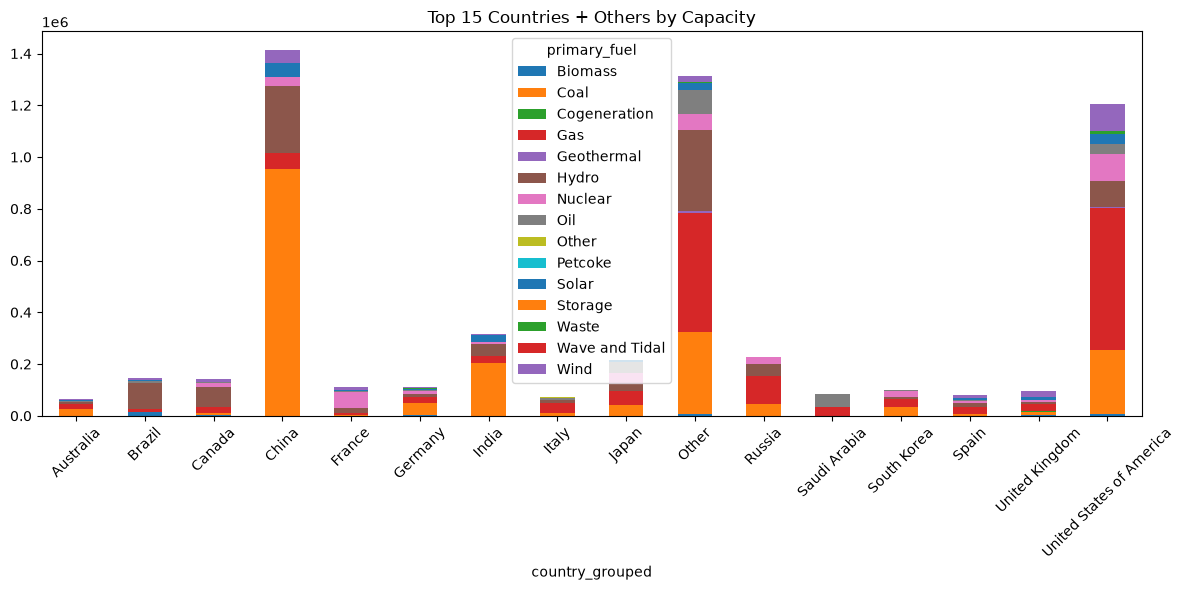

In [30]:
# 1. Group by country and sum capacity
country_cap = df_clean4.groupby('country_long')['capacity_mw'].sum().sort_values(ascending=False)

# 2. Keep top 15, sum the rest as 'Other'
top_n = 15
top_countries = country_cap.index[:top_n].tolist()
df_clean4['country_grouped'] = df_clean4['country_long'].apply(lambda x: x if x in top_countries else 'Other')

# 3. Plot using the new grouped column
df_grouped = df_clean4.groupby(['country_grouped', 'primary_fuel'])['capacity_mw'].sum().unstack()
df_grouped.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title(f'Top {top_n} Countries + Others by Capacity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()   

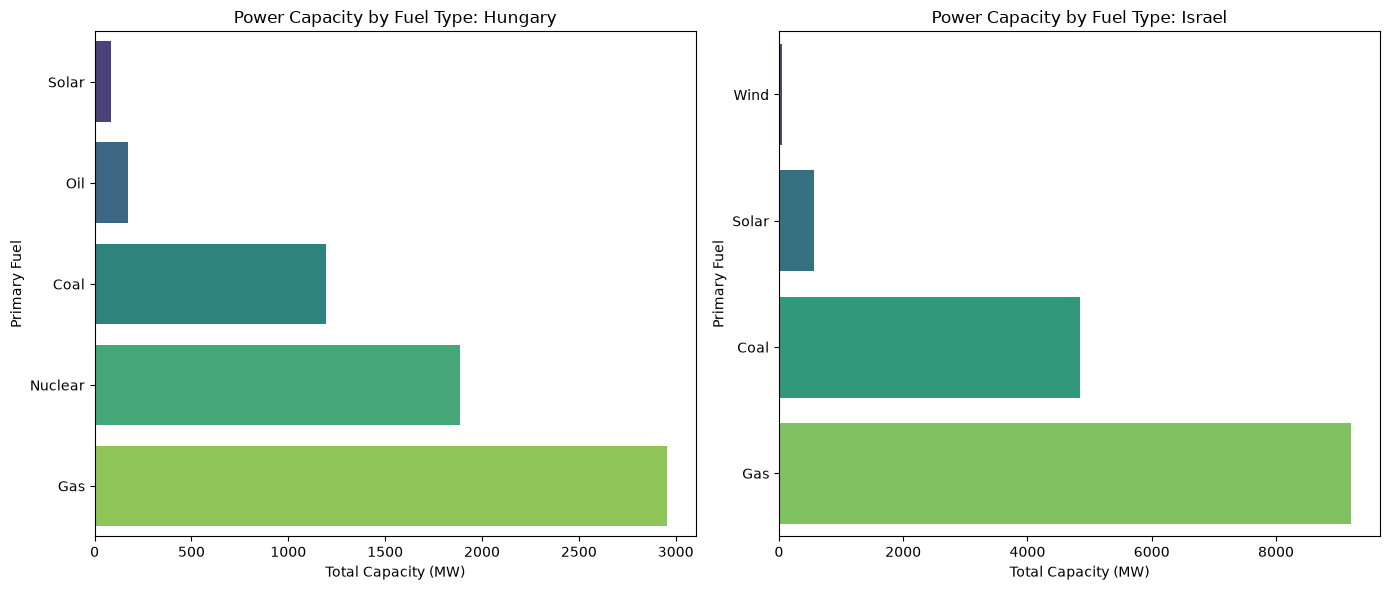

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, country in zip(axes, ['Hungary', 'Israel']):
    country_mix = (
        df[df['country_long'] == country]
        .groupby('primary_fuel')['capacity_mw']
        .sum()
        .sort_values()
    )

    sns.barplot(
        x=country_mix.values,
        y=country_mix.index,
        hue=country_mix.index,
        palette='viridis',
        legend=False,
        ax=ax
    )

    ax.set_title(f'Power Capacity by Fuel Type: {country}')
    ax.set_xlabel('Total Capacity (MW)')
    ax.set_ylabel('Primary Fuel')

plt.tight_layout()
plt.show()

# Plant-count distributions complement the capacity-based charts above.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

country_counts = df['country_long'].value_counts().head(15).sort_values()
fuel_counts = df['primary_fuel'].value_counts().sort_values()

country_counts.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Countries by Number of Power Plants')
axes[0].set_xlabel('Number of Plants')
axes[0].set_ylabel('Country')

fuel_counts.plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title('Number of Power Plants by Fuel Type')
axes[1].set_xlabel('Number of Plants')
axes[1].set_ylabel('Primary Fuel')

plt.tight_layout()
plt.show()

3. Statistical Analysis:

 - Perform a statistical analysis of power output by fuel type using NumPy’s statistical functions.
 - Use hypothesis testing to determine if the mean power output differs significantly between different fuel types.

In [35]:
# Select the column to analyze (e.g., Capacity)
target_col = 'capacity_mw'

# Get unique fuel types
fuel_types = df['primary_fuel'].unique()

In [36]:
print(f"{'Fuel Type':<15} | {'Count':<6} | {'Mean (MW)':<10} | {'Median (MW)':<12} | {'Std Dev':<10} | {'Min (MW)':<10} | {'Max (MW)':<10}")
print("-" * 90)

stats_results = {}

for fuel in fuel_types:
    # Filter data for the specific fuel type
    data = df[df['primary_fuel'] == fuel][target_col].dropna()
    
    if len(data) > 0:
        # NumPy statistical functions
        mean_val = np.mean(data)
        median_val = np.median(data)
        std_dev = np.std(data, ddof=1)
        variance = np.var(data, ddof=1)
        min_val = np.min(data)
        max_val = np.max(data)
        p25 = np.percentile(data, 25)
        p75 = np.percentile(data, 75)
        
        # Store for later use (optional)
        stats_results[fuel] = {
            'count': len(data),
            'mean': mean_val,
            'median': median_val,
            'std': std_dev,
            'min': min_val,
            'max': max_val,
            '25th_percentile': p25,
            '75th_percentile': p75
        }
        
        # Print row
        print(f"{fuel:<15} | {len(data):<6} | {mean_val:<10.2f} | {median_val:<12.2f} | {std_dev:<10.2f} | {min_val:<10.2f} | {max_val:<10.2f}")

Fuel Type       | Count  | Mean (MW)  | Median (MW)  | Std Dev    | Min (MW)   | Max (MW)  
------------------------------------------------------------------------------------------
Hydro           | 7156   | 147.17     | 20.00        | 549.77     | 1.00       | 22500.00  
Solar           | 10665  | 17.66      | 5.80         | 41.94      | 1.00       | 1021.00   
Gas             | 3998   | 373.45     | 147.50       | 560.86     | 1.00       | 8865.00   
Other           | 43     | 84.02      | 40.00        | 144.19     | 4.50       | 845.26    
Oil             | 2320   | 112.88     | 9.00         | 391.92     | 1.00       | 6794.00   
Wind            | 5344   | 49.22      | 27.00        | 106.13     | 1.00       | 6000.00   
Nuclear         | 195    | 2091.86    | 1888.00      | 1300.16    | 20.00      | 8212.00   
Coal            | 2330   | 843.58     | 600.00       | 888.00     | 1.20       | 7000.00   
Waste           | 1068   | 13.81      | 4.80         | 20.57      | 1.00       | 

C:\Users\elemk\AppData\Local\Temp\ipykernel_34020\994631883.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_to_plot, x='primary_fuel', y=target_col, palette='viridis')


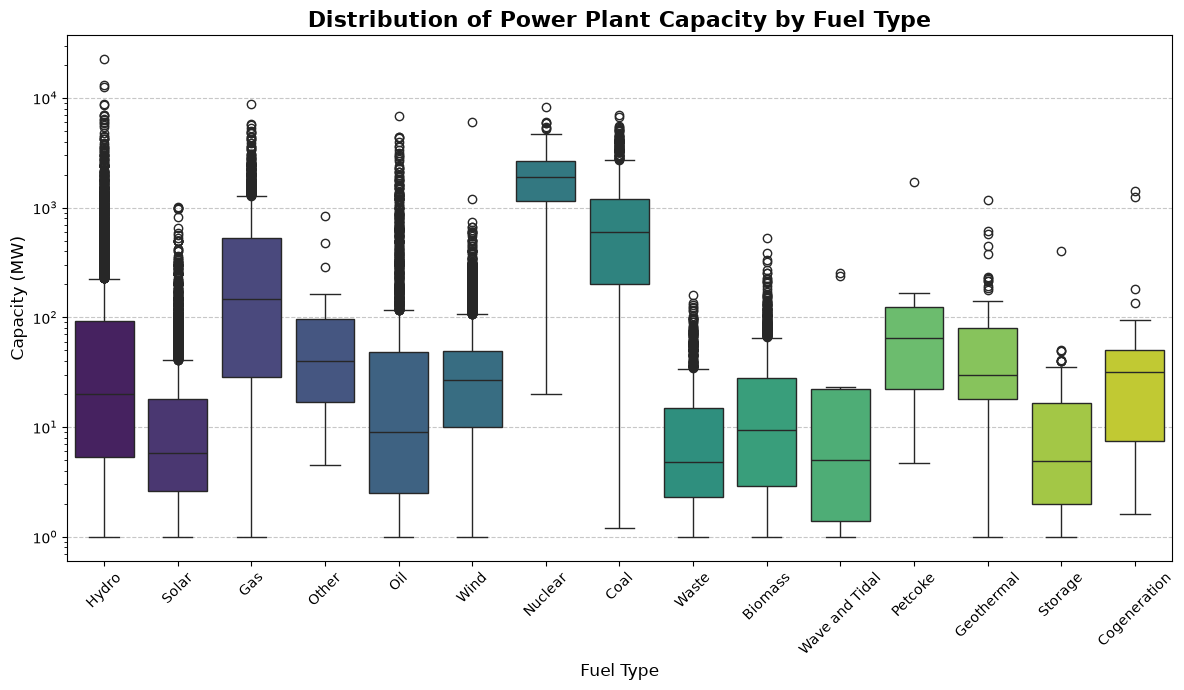

In [37]:
plt.figure(figsize=(12, 7))

# Create boxplot
# We drop NaNs explicitly to avoid warnings
data_to_plot = df[['primary_fuel', target_col]].dropna()

sns.boxplot(
    data=data_to_plot,
    x='primary_fuel',
    y=target_col,
    hue='primary_fuel',
    palette='viridis',
    legend=False
)

plt.title('Distribution of Power Plant Capacity by Fuel Type', fontsize=16, weight='bold')
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Capacity (MW)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set y-axis to log scale if data is heavily skewed (optional but recommended for power data)
plt.yscale('log') 

plt.tight_layout()
plt.show()

In [38]:
from scipy import stats

# H0: Mean power capacity is equal across all fuel types.
# H1: At least one fuel type has a different mean power capacity.

groups = [
    group['capacity_mw'].dropna().to_numpy()
    for _, group in df.groupby('primary_fuel')
]

# Welch's ANOVA handles unequal variances and group sizes
result = stats.f_oneway(*groups, equal_var=False)

print(f"Welch F-statistic: {result.statistic:.2f}")
print(f"p-value: {result.pvalue:.4e}")

if result.pvalue < 0.05:
    print(
        "Reject H0: mean power capacity differs significantly "
        "for at least one fuel type."
    )
else:
    print(
        "Fail to reject H0: there is insufficient evidence "
        "of a difference in mean power output."
    )

Welch F-statistic: 359.96
p-value: 7.5776e-168
Reject H0: mean power capacity differs significantly for at least one fuel type.


4. Time Series Analysis:

 - If the dataset includes time-related data (like year of establishment), use NumPy to analyze trends over time.
 - Explore how the mix of fuel types for power generation has evolved over the years.


In [40]:
# Keep plants with an actual commissioning year
time_data = df[
    ['commissioning_year', 'primary_fuel', 'capacity_mw']
].dropna().copy()

# Remove implausible years and convert to integers
time_data = time_data[
    time_data['commissioning_year'].between(
        1800, pd.Timestamp.today().year
    )
]

time_data['commissioning_year'] = (
    time_data['commissioning_year'].round().astype(int)
)

coverage = len(time_data) / len(df) * 100

print(f"Plants with known commissioning year: {len(time_data):,}")
print(f"Dataset coverage: {coverage:.1f}%")
print(
    f"Period: {time_data['commissioning_year'].min()}–"
    f"{time_data['commissioning_year'].max()}"
)

Plants with known commissioning year: 17,447
Dataset coverage: 49.9%
Period: 1896–2020


In [41]:
# Capacity commissioned each year, separated by fuel type
annual_capacity = time_data.pivot_table(
    index='commissioning_year',
    columns='primary_fuel',
    values='capacity_mw',
    aggfunc='sum',
    fill_value=0
)

# Include years in which no plants were commissioned
years = np.arange(
    annual_capacity.index.min(),
    annual_capacity.index.max() + 1
)

annual_capacity = annual_capacity.reindex(years, fill_value=0)

total_annual_capacity = annual_capacity.sum(axis=1)

# Five-year moving average using NumPy
window = 5
moving_average = np.convolve(
    total_annual_capacity.to_numpy(),
    np.ones(window) / window,
    mode='valid'
)

moving_average_years = years[window - 1:]

# Linear trend over the most recent 30 years
recent = total_annual_capacity.iloc[-30:]

slope, intercept = np.polyfit(
    recent.index.to_numpy(),
    recent.to_numpy(),
    deg=1
)

print(
    f"Change in annual capacity additions: {slope:,.2f} MW per year"
)

if slope > 0:
    print("Annual additions of generation capacity have increased.")
else:
    print("Annual additions of generation capacity have decreased.")

Change in annual capacity additions: 1,766.99 MW per year
Annual additions of generation capacity have increased.


In [42]:
# Cumulative capacity assumes plants remain operational
cumulative_capacity = annual_capacity.cumsum()

# Keep the largest fuel types and combine smaller ones
top_fuels = (
    cumulative_capacity.iloc[-1]
    .nlargest(7)
    .index
)

fuel_mix = cumulative_capacity[top_fuels].copy()

other_fuels = cumulative_capacity.columns.difference(top_fuels)
fuel_mix['Other'] = cumulative_capacity[other_fuels].sum(axis=1)

# Convert cumulative capacity into percentages
fuel_mix_percent = fuel_mix.div(
    fuel_mix.sum(axis=1),
    axis=0
) * 100

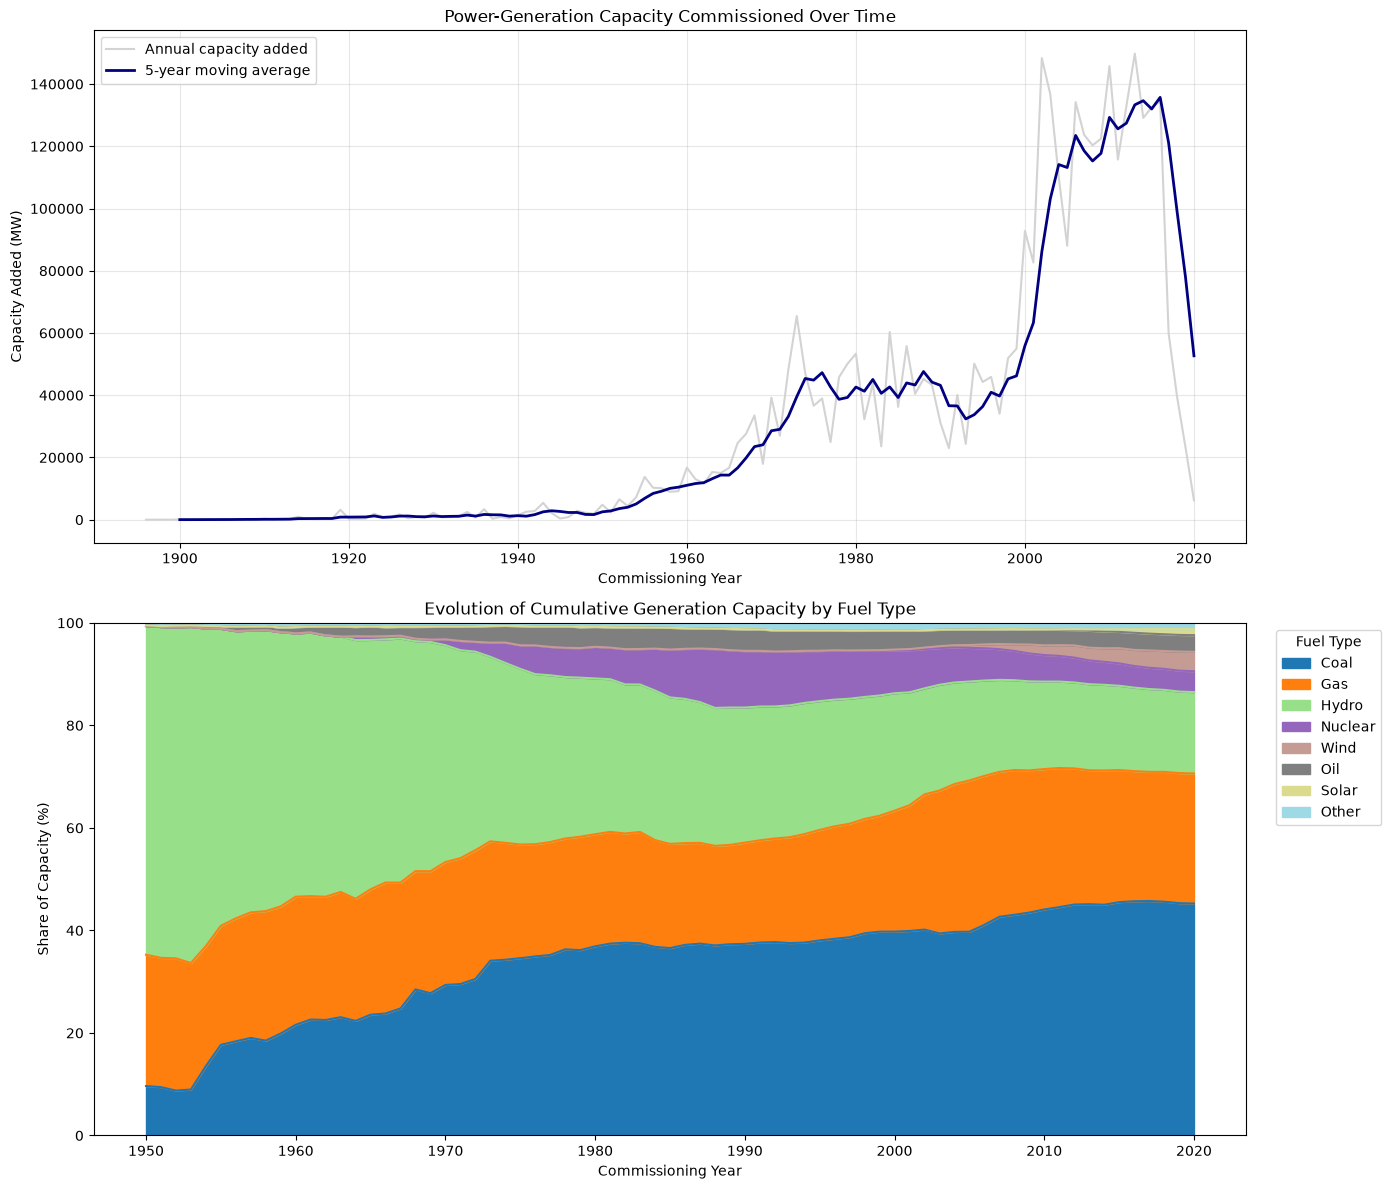

In [43]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Annual capacity additions
axes[0].plot(
    total_annual_capacity.index,
    total_annual_capacity,
    color='lightgray',
    label='Annual capacity added'
)

axes[0].plot(
    moving_average_years,
    moving_average,
    color='navy',
    linewidth=2,
    label='5-year moving average'
)

axes[0].set_title('Power-Generation Capacity Commissioned Over Time')
axes[0].set_xlabel('Commissioning Year')
axes[0].set_ylabel('Capacity Added (MW)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cumulative fuel mix
fuel_mix_percent.loc[1950:].plot.area(
    stacked=True,
    ax=axes[1],
    colormap='tab20'
)

axes[1].set_title('Evolution of Cumulative Generation Capacity by Fuel Type')
axes[1].set_xlabel('Commissioning Year')
axes[1].set_ylabel('Share of Capacity (%)')
axes[1].set_ylim(0, 100)
axes[1].legend(
    title='Fuel Type',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Time-Series Interpretation

Among plants with a reported commissioning year, annual additions to generation capacity generally increased during the most recent 30-year period. The cumulative capacity mix shifted from being dominated by hydroelectric capacity in earlier years toward larger shares of coal and gas, while wind and solar appeared more prominently in recent decades.

Only 49.9% of plants have a reported commissioning year. The dataset also does not contain retirement dates. Therefore, the cumulative chart assumes plants remain operational and should not be interpreted as the exact historical global operating fleet.

5. Advanced Visualization:

 - Create visualizations using Matplotlib and Seaborn to illustrate your findings.
 - Consider plotting the geographical distribution of power plants using latitude and longitude data, if available.

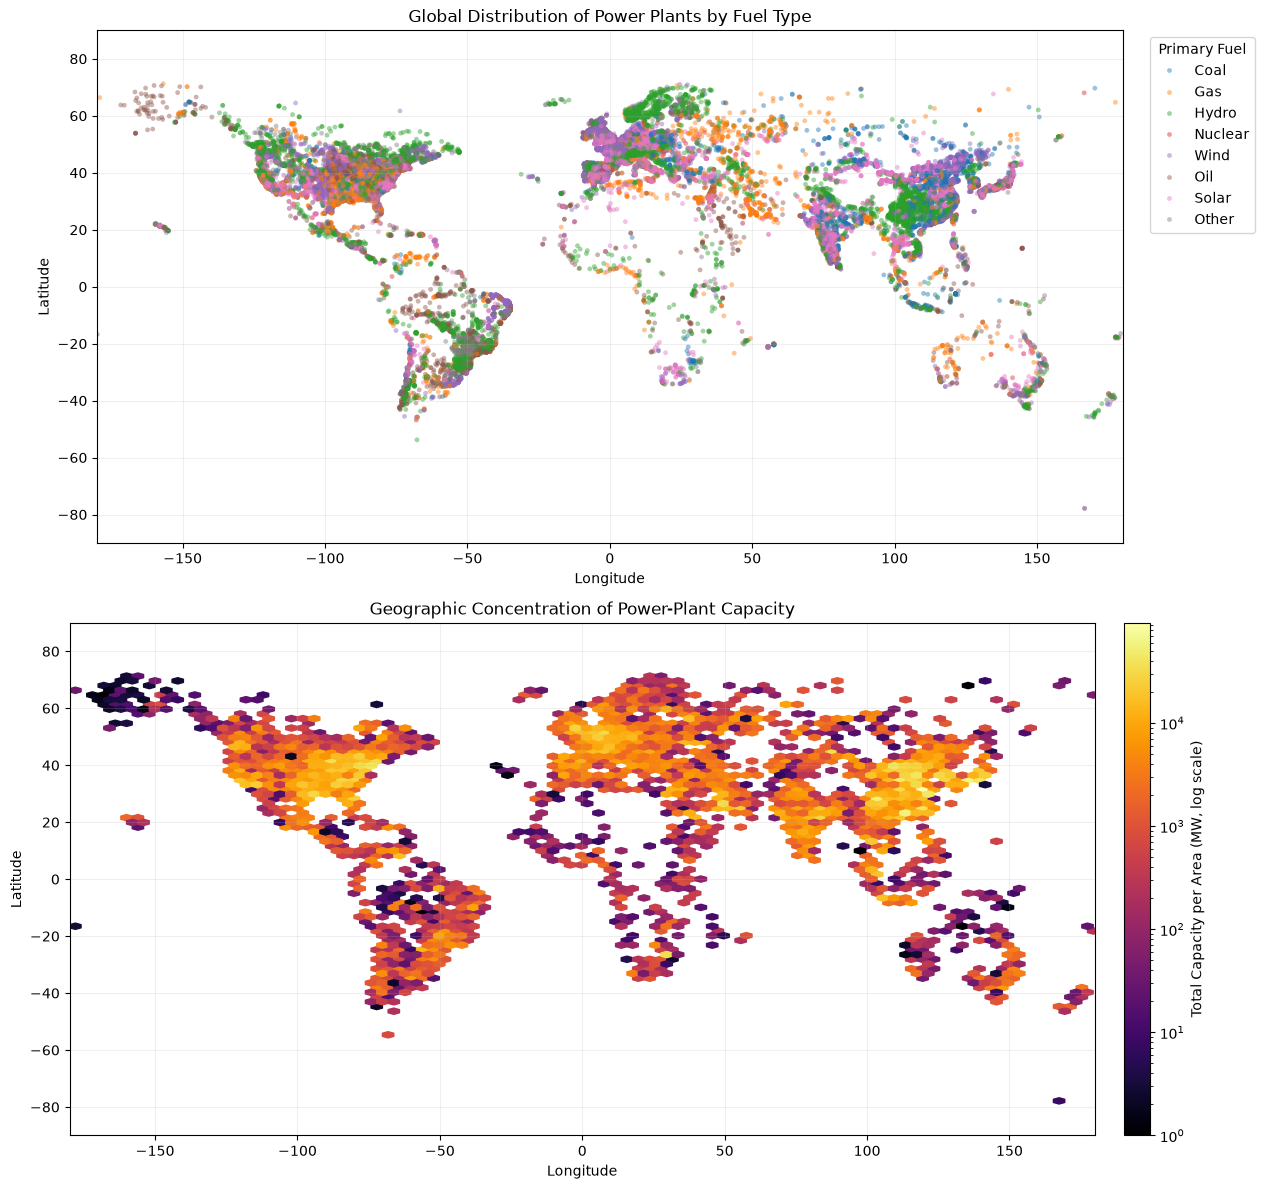

In [45]:
# Use original geographic and capacity data
geo_data = df[
    ['longitude', 'latitude', 'primary_fuel', 'capacity_mw']
].dropna().copy()

# Keep valid coordinates and positive capacities
geo_data = geo_data[
    geo_data['longitude'].between(-180, 180)
    & geo_data['latitude'].between(-90, 90)
    & (geo_data['capacity_mw'] > 0)
]

# Show the largest fuel categories separately
top_fuels = (
    geo_data.groupby('primary_fuel')['capacity_mw']
    .sum()
    .nlargest(7)
    .index
)

geo_data['fuel_group'] = np.where(
    geo_data['primary_fuel'].isin(top_fuels),
    geo_data['primary_fuel'],
    'Other'
)

fuel_order = list(top_fuels) + ['Other']

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# ---------------------------------------------------------
# 1. Geographic distribution by fuel type
# ---------------------------------------------------------

sns.scatterplot(
    data=geo_data,
    x='longitude',
    y='latitude',
    hue='fuel_group',
    hue_order=fuel_order,
    palette='tab10',
    s=12,
    alpha=0.45,
    linewidth=0,
    ax=axes[0]
)

axes[0].set_title('Global Distribution of Power Plants by Fuel Type')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_xlim(-180, 180)
axes[0].set_ylim(-90, 90)
axes[0].set_aspect('equal', adjustable='box')
axes[0].grid(alpha=0.2)
axes[0].legend(
    title='Primary Fuel',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# ---------------------------------------------------------
# 2. Geographic concentration of generation capacity
# ---------------------------------------------------------

capacity_map = axes[1].hexbin(
    geo_data['longitude'],
    geo_data['latitude'],
    C=geo_data['capacity_mw'],
    reduce_C_function=np.sum,
    gridsize=(90, 45),
    mincnt=1,
    cmap='inferno',
    norm=LogNorm()
)

axes[1].set_title('Geographic Concentration of Power-Plant Capacity')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_xlim(-180, 180)
axes[1].set_ylim(-90, 90)
axes[1].set_aspect('equal', adjustable='box')
axes[1].grid(alpha=0.2)

colorbar = fig.colorbar(capacity_map, ax=axes[1], pad=0.02)
colorbar.set_label('Total Capacity per Area (MW, log scale)')

plt.tight_layout()
plt.show()

6. Matrix Operations in Real-World Context:

 - Demonstrate matrix operations by analyzing relationships between different attributes (e.g., fuel type, capacity, and geographic location).
 - Discuss the relevance of eigenvectors and eigenvalues in this context.

In [47]:
# Select relevant attributes
matrix_data = df[
    ['primary_fuel', 'capacity_mw', 'latitude', 'longitude']
].dropna().copy()

matrix_data = matrix_data[
    (matrix_data['capacity_mw'] > 0)
    & matrix_data['latitude'].between(-90, 90)
    & matrix_data['longitude'].between(-180, 180)
]

# Reduce the strong positive skew in plant capacity
matrix_data['log_capacity'] = np.log1p(
    matrix_data['capacity_mw']
)

# Convert latitude and longitude into spherical coordinates
latitude_rad = np.radians(matrix_data['latitude'])
longitude_rad = np.radians(matrix_data['longitude'])

matrix_data['geo_x'] = (
    np.cos(latitude_rad) * np.cos(longitude_rad)
)

matrix_data['geo_y'] = (
    np.cos(latitude_rad) * np.sin(longitude_rad)
)

matrix_data['geo_z'] = np.sin(latitude_rad)

feature_names = [
    'log_capacity',
    'geo_x',
    'geo_y',
    'geo_z'
]

# Each row represents a plant; each column represents an attribute
X = matrix_data[feature_names].to_numpy(dtype=float)

print(f"Feature-matrix shape: {X.shape}")

Feature-matrix shape: (34936, 4)


In [48]:
feature_means = X.mean(axis=0)
feature_std = X.std(axis=0, ddof=1)

Z = (X - feature_means) / feature_std

In [49]:
n = Z.shape[0]

correlation_matrix = (Z.T @ Z) / (n - 1)

correlation_df = pd.DataFrame(
    correlation_matrix,
    index=feature_names,
    columns=feature_names
)

display(correlation_df.round(3))

,log_capacity,geo_x,geo_y,geo_z
log_capacity,1.000,-0.191,0.246,-0.046
geo_x,-0.191,1.000,-0.089,0.025
geo_y,0.246,-0.089,1.000,0.070
geo_z,-0.046,0.025,0.070,1.000


In [50]:
eigenvalues, eigenvectors = np.linalg.eigh(
    correlation_matrix
)

# Sort from largest to smallest eigenvalue
order = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

explained_variance = (
    eigenvalues / eigenvalues.sum()
)

loadings = pd.DataFrame(
    eigenvectors,
    index=feature_names,
    columns=[
        f'PC{i + 1}'
        for i in range(len(feature_names))
    ]
)

print("Explained variance:")
display(
    pd.DataFrame({
        'Eigenvalue': eigenvalues,
        'Explained Variance (%)': explained_variance * 100
    }).round(2)
)

print("Eigenvector loadings:")
display(loadings.round(3))

Explained variance:


,Eigenvalue,Explained Variance (%)
0,1.36,33.95
1,1.04,26.01
2,0.89,22.25
3,0.71,17.80


Eigenvector loadings:


,PC1,PC2,PC3,PC4
log_capacity,0.656,-0.101,-0.191,-0.723
geo_x,-0.492,0.261,-0.783,-0.277
geo_y,0.571,0.354,-0.450,0.588
geo_z,-0.008,0.892,0.386,-0.234


In [51]:
pca_scores = Z @ eigenvectors

matrix_data['PC1'] = pca_scores[:, 0]
matrix_data['PC2'] = pca_scores[:, 1]

In [52]:
fuel_matrix = pd.get_dummies(
    matrix_data['primary_fuel'],
    dtype=float
)

fuel_counts = (
    fuel_matrix.to_numpy().sum(axis=0)[:, np.newaxis]
)

fuel_centroids = (
    fuel_matrix.to_numpy().T
    @ pca_scores[:, :2]
) / fuel_counts

fuel_centroids = pd.DataFrame(
    fuel_centroids,
    index=fuel_matrix.columns,
    columns=['PC1', 'PC2']
)

display(fuel_centroids.round(3))

,PC1,PC2
Biomass,-0.736,-0.528
Coal,1.791,0.008
Cogeneration,-0.248,-0.204
Gas,0.530,-0.234
Geothermal,0.410,-0.302
Hydro,0.064,-0.107
Nuclear,1.557,0.017
Oil,-0.543,-0.881
Other,-0.008,0.125
Petcoke,-0.084,-0.627


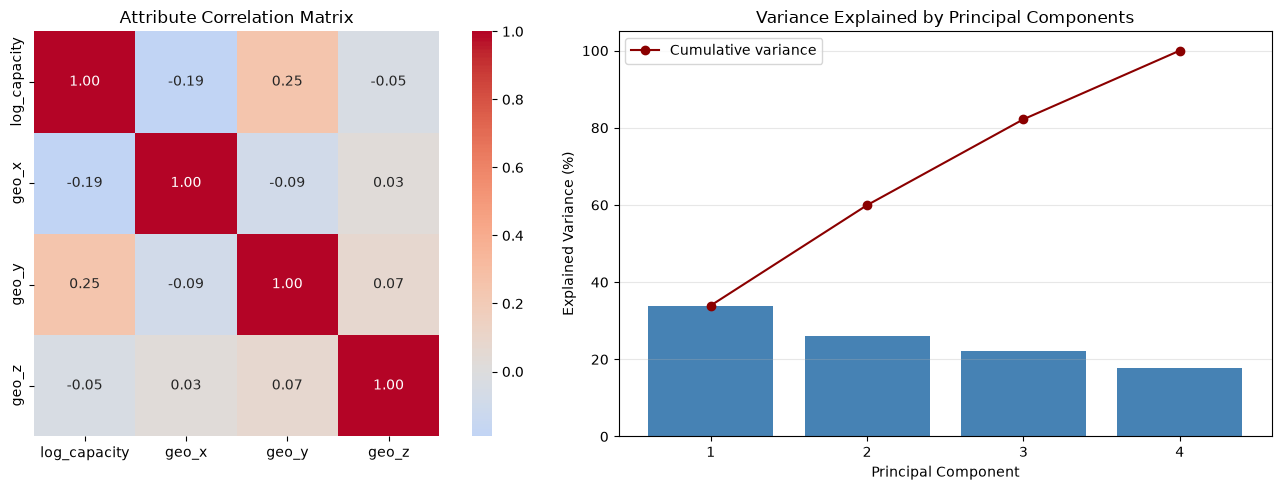

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Attribute correlation matrix
sns.heatmap(
    correlation_df,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    ax=axes[0]
)

axes[0].set_title('Attribute Correlation Matrix')

# Eigenvalue/scree plot
axes[1].bar(
    range(1, len(eigenvalues) + 1),
    explained_variance * 100,
    color='steelblue'
)

axes[1].plot(
    range(1, len(eigenvalues) + 1),
    np.cumsum(explained_variance) * 100,
    marker='o',
    color='darkred',
    label='Cumulative variance'
)

axes[1].set_title('Variance Explained by Principal Components')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance (%)')
axes[1].set_xticks(range(1, len(eigenvalues) + 1))
axes[1].set_ylim(0, 105)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

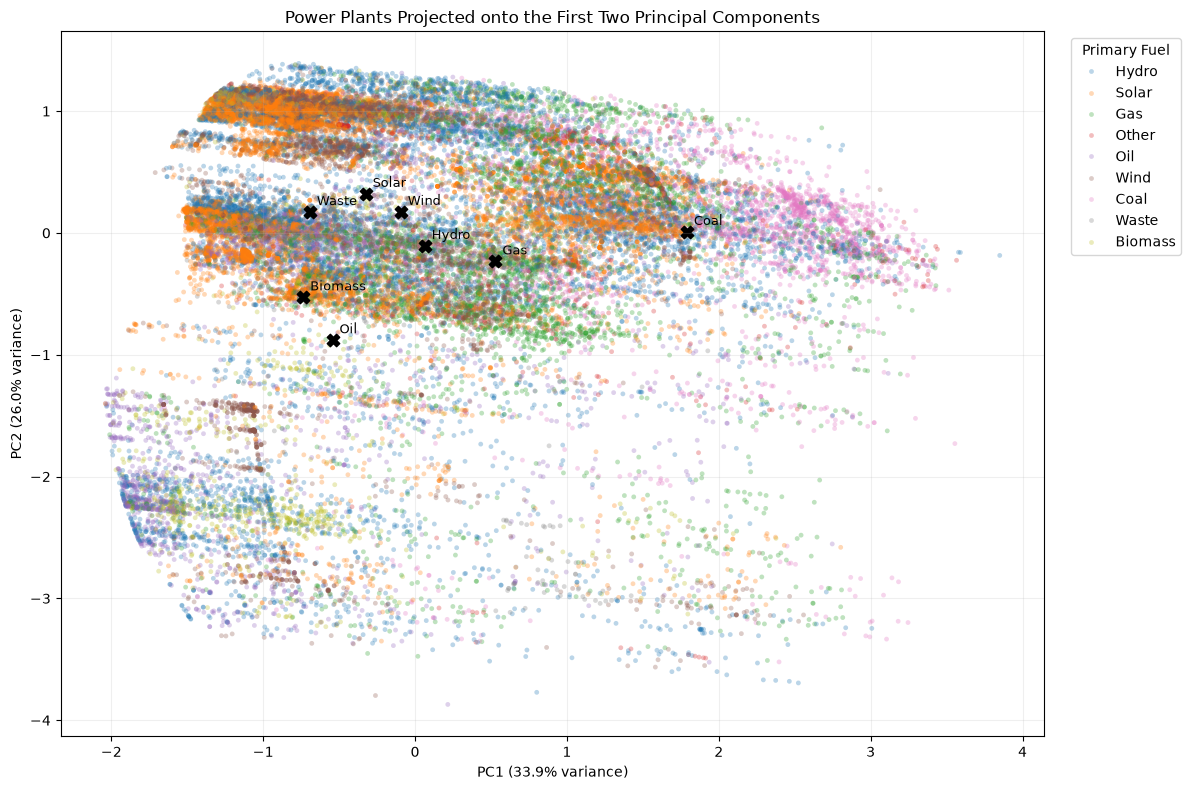

In [54]:
# Group less-common fuels for a clearer PCA plot
top_fuels = (
    matrix_data['primary_fuel']
    .value_counts()
    .head(8)
    .index
)

matrix_data['fuel_group'] = np.where(
    matrix_data['primary_fuel'].isin(top_fuels),
    matrix_data['primary_fuel'],
    'Other'
)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=matrix_data,
    x='PC1',
    y='PC2',
    hue='fuel_group',
    palette='tab10',
    s=12,
    alpha=0.3,
    linewidth=0
)

# Mark the centroids of the largest fuel groups
for fuel in top_fuels:
    x = fuel_centroids.loc[fuel, 'PC1']
    y = fuel_centroids.loc[fuel, 'PC2']

    plt.scatter(
        x,
        y,
        color='black',
        marker='X',
        s=80
    )

    plt.annotate(
        fuel,
        (x, y),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

plt.title('Power Plants Projected onto the First Two Principal Components')
plt.xlabel(f'PC1 ({explained_variance[0] * 100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_variance[1] * 100:.1f}% variance)')
plt.legend(
    title='Primary Fuel',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Relevance of Eigenvalues and Eigenvectors

The eigenvectors define combinations of plant capacity and geographic coordinates along which the dataset varies most. Their loadings indicate which attributes contribute most strongly to each principal component.

The eigenvalues measure how much variation is captured by each eigenvector. PC1 explains approximately 34% of the variation and PC2 explains approximately 26%. Together, the first two components preserve about 60% of the variation in capacity and geographic location.

PC1 combines plant capacity with east-west geographic patterns, while PC2 is primarily associated with north-south location. Comparing fuel-type centroids in this reduced space helps identify fuel types whose plants tend to have different capacity and geographic patterns.

PCA reveals associations rather than causal relationships. The sign of an eigenvector is arbitrary; reversing all its signs does not change its meaning.

7. Integrating NumPy with Pandas and Matplotlib:

 - Show how NumPy can be used to enhance data manipulation in Pandas and data visualization in Matplotlib.
 - Provide examples, such as using NumPy arrays for complex filtering in Pandas or for creating sophisticated plots in Matplotlib.

In [55]:
generation_cols = [
    f'generation_gwh_{year}'
    for year in range(2013, 2020)
    if f'generation_gwh_{year}' in df.columns
]

# Convert Pandas columns into NumPy arrays
generation_array = df[generation_cols].to_numpy(dtype=float)
capacity_array = df['capacity_mw'].to_numpy(dtype=float)

# Broadcasting: one maximum value per plant applied across all years
annual_max_gwh = capacity_array[:, np.newaxis] * 8.76

# A value is valid if it is present, nonnegative, and physically possible
valid_generation = (
    np.isfinite(generation_array)
    & (generation_array >= 0)
    & (generation_array <= annual_max_gwh)
)

# Replace invalid values with NaN
clean_generation = np.where(
    valid_generation,
    generation_array,
    np.nan
)

valid_year_count = valid_generation.sum(axis=1)
generation_sum = np.nansum(clean_generation, axis=1)

# Safely calculate the mean without dividing by zero
mean_annual_generation = np.divide(
    generation_sum,
    valid_year_count,
    out=np.full(len(df), np.nan),
    where=valid_year_count > 0
)

mean_capacity_factor = np.divide(
    mean_annual_generation,
    capacity_array * 8.76,
    out=np.full(len(df), np.nan),
    where=(
        (capacity_array > 0)
        & np.isfinite(mean_annual_generation)
    )
)

# Return the NumPy results to a Pandas DataFrame
integrated_df = df.copy()

integrated_df['valid_generation_years'] = valid_year_count
integrated_df['mean_annual_generation_gwh'] = mean_annual_generation
integrated_df['mean_capacity_factor'] = mean_capacity_factor

integrated_df[
    [
        'name',
        'primary_fuel',
        'capacity_mw',
        'valid_generation_years',
        'mean_annual_generation_gwh',
        'mean_capacity_factor'
    ]
].head()

,name,primary_fuel,capacity_mw,valid_generation_years,mean_annual_generation_gwh,mean_capacity_factor
0,Kajaki Hydroelectric Power Plant Afghanistan,Hydro,33.0,0,NaN,NaN
1,Kandahar DOG,Solar,10.0,0,NaN,NaN
2,Kandahar JOL,Solar,10.0,0,NaN,NaN
3,Mahipar Hydroelectric Power Plant Afghanistan,Hydro,66.0,0,NaN,NaN
4,Naghlu Dam Hydroelectric Power Plant Afghanistan,Hydro,100.0,0,NaN,NaN


In [56]:
renewable_fuels = np.array([
    'Hydro',
    'Wind',
    'Solar',
    'Geothermal',
    'Biomass',
    'Waste',
    'Wave and Tidal'
])

fuel_array = integrated_df['primary_fuel'].to_numpy()
year_array = integrated_df['commissioning_year'].to_numpy(dtype=float)
latitude_array = integrated_df['latitude'].to_numpy(dtype=float)
longitude_array = integrated_df['longitude'].to_numpy(dtype=float)

is_renewable = np.isin(
    fuel_array,
    renewable_fuels
)

# Define "large" as the upper 25% of renewable plant capacities
renewable_capacity_threshold = np.nanpercentile(
    capacity_array[is_renewable],
    75
)

complex_filter = (
    is_renewable
    & np.isfinite(year_array)
    & (year_array >= 2000)
    & (capacity_array >= renewable_capacity_threshold)
    & (valid_year_count >= 3)
    & np.isfinite(latitude_array)
    & np.isfinite(longitude_array)
)

large_recent_renewables = integrated_df.loc[
    complex_filter,
    [
        'name',
        'country_long',
        'primary_fuel',
        'commissioning_year',
        'capacity_mw',
        'mean_annual_generation_gwh'
    ]
].sort_values(
    'capacity_mw',
    ascending=False
)

print(
    f"Renewable capacity threshold: "
    f"{renewable_capacity_threshold:.2f} MW"
)
print(
    f"Plants matching all conditions: "
    f"{len(large_recent_renewables):,}"
)

display(large_recent_renewables.head(10))

Renewable capacity threshold: 40.00 MW
Plants matching all conditions: 840


,name,country_long,primary_fuel,commissioning_year,capacity_mw,mean_annual_generation_gwh
15029,NATHPA JHAKRI,India,Hydro,2003.000000,1500.0,6948.445190
15294,S.SAROVAR RBPH,India,Hydro,2005.000000,1200.0,1288.148890
15464,TEESTA-III,India,Hydro,2017.000000,1200.0,2984.054750
33962,Wanapum,United States of America,Hydro,2014.333333,1098.0,4866.359857
14604,INDIRA SAGAR,India,Hydro,2004.000000,1000.0,1995.462550
14668,KARCHAM WANGTOO,India,Hydro,2011.000000,1000.0,4353.654340
15465,TEHRI ST -1,India,Hydro,2006.000000,1000.0,3089.254110
15348,SRISAILAM LBPH,India,Hydro,2001.000000,900.0,873.186130
15144,PURULIA PSS,India,Hydro,2007.000000,900.0,1134.045280
14694,KOLDAM,India,Hydro,2015.000000,800.0,2360.450690


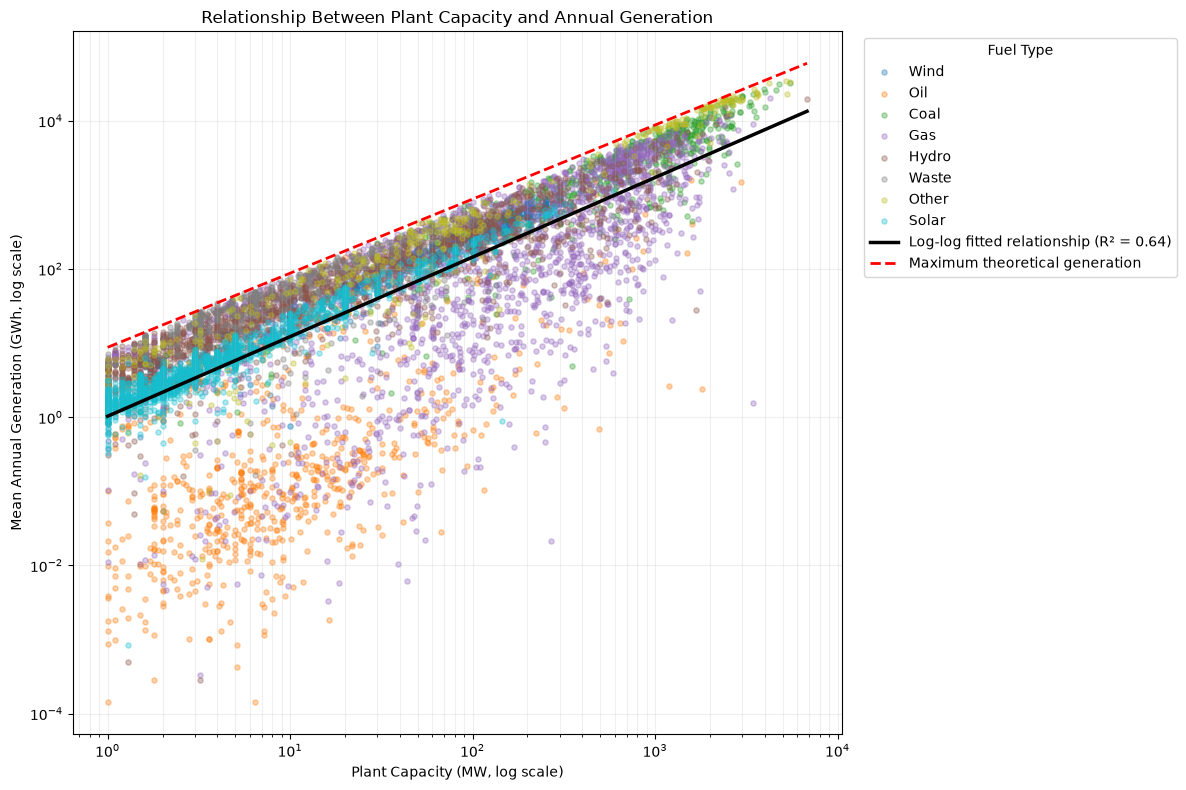

Regression slope: 1.074
R²: 0.636


In [57]:
plot_data = integrated_df[
    (integrated_df['valid_generation_years'] >= 3)
    & (integrated_df['capacity_mw'] > 0)
    & (integrated_df['mean_annual_generation_gwh'] > 0)
].copy()

# Combine less-common fuel types
top_fuels = (
    plot_data['primary_fuel']
    .value_counts()
    .head(7)
    .index
)

plot_data['fuel_group'] = np.where(
    plot_data['primary_fuel'].isin(top_fuels),
    plot_data['primary_fuel'],
    'Other'
)

# Fit a linear relationship after log transformation
log_capacity = np.log10(
    plot_data['capacity_mw'].to_numpy()
)

log_generation = np.log10(
    plot_data['mean_annual_generation_gwh'].to_numpy()
)

coefficients = np.polyfit(
    log_capacity,
    log_generation,
    deg=1
)

predicted_log_generation = np.polyval(
    coefficients,
    log_capacity
)

r_squared = 1 - (
    np.sum(
        (log_generation - predicted_log_generation) ** 2
    )
    / np.sum(
        (log_generation - log_generation.mean()) ** 2
    )
)

# Values used to draw smooth lines
capacity_line = np.logspace(
    log_capacity.min(),
    log_capacity.max(),
    200
)

generation_fit = 10 ** np.polyval(
    coefficients,
    np.log10(capacity_line)
)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

fuel_groups = plot_data['fuel_group'].unique()

colors = plt.cm.tab10(
    np.linspace(0, 1, len(fuel_groups))
)

for fuel, color in zip(fuel_groups, colors):
    fuel_data = plot_data[
        plot_data['fuel_group'] == fuel
    ]

    ax.scatter(
        fuel_data['capacity_mw'],
        fuel_data['mean_annual_generation_gwh'],
        s=14,
        alpha=0.35,
        color=color,
        label=fuel
    )

# NumPy regression line
ax.plot(
    capacity_line,
    generation_fit,
    color='black',
    linewidth=2.5,
    label=(
        f'Log-log fitted relationship '
        f'(R² = {r_squared:.2f})'
    )
)

# Physical maximum generation reference line
ax.plot(
    capacity_line,
    capacity_line * 8.76,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Maximum theoretical generation'
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title(
    'Relationship Between Plant Capacity and Annual Generation'
)
ax.set_xlabel('Plant Capacity (MW, log scale)')
ax.set_ylabel('Mean Annual Generation (GWh, log scale)')
ax.grid(alpha=0.2, which='both')

ax.legend(
    title='Fuel Type',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

print(f"Regression slope: {coefficients[0]:.3f}")
print(f"R²: {r_squared:.3f}")